In [2]:
!pip install googletrans==4.0.0-rc1

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 4.3 MB/s eta 0:00:00
  Created wheel for googletrans: filename=googletrans-4.0.0rc1-py3-none-any.whl size=17396 sha256=f506da34fc964e305de4027b6f68b811c181d876bb4058e75d000e833ff86e47
  Stored in directory: /root/.cache/pip/wheels/95/0f/04/b17a72024b56a60e499ce1a6313d283ed5ba332407155bee03
Successfully built googletrans
  Attempting uninstall: hyperframe
    Found existing installation: hyperframe 6.1.0
    Uninstalling hyperfram

In [3]:
import sys
from google.colab import drive
drive.mount('/content/drive')

# Add the folder containing your .py file to the system path
sys.path.append('/content/drive/MyDrive/Data MINIPROJECT/RecycleEasy_Project/ai_engine/')

import recycling_engine as re

# Load your CSV using the engine's function
df = re.load_recycling_db('/content/drive/MyDrive/Data MINIPROJECT/RecycleEasy_Project/ai_engine/global_data/global_bin_colors.csv')

# Get results for any country!
final_result = re.get_global_guidance('plastic', 'Japan', df)
print(final_result)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Database loaded successfully from: /content/drive/MyDrive/Data MINIPROJECT/RecycleEasy_Project/ai_engine/global_data/global_bin_colors.csv
{'country': 'Japan', 'language': 'ja', 'material': 'PLASTIC', 'lifecycle': 'リサイクル可能', 'action': 'リサイクルマークを確認してください。キャップを外し、ボトルを潰します。', 'safety': '⚠️ 液体に関する警告: 廃棄する前に、容器が 100% 空であることを確認してください。', 'bin': 'PINK/CLEAR BIN'}


In [4]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive, files
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Add the path to the folder where you saved 'recycling_engine.py'
# Example: '/content/drive/MyDrive/Data MINIPROJECT/RecycleEasy_Project/ai_engine/'
ENGINE_PATH = '/content/drive/MyDrive/Data MINIPROJECT/RecycleEasy_Project/ai_engine/'
sys.path.append(ENGINE_PATH)

# 3. Import your custom engine
import recycling_engine as re

# 4. Load the Model and CSV Database
MODEL_PATH = '/content/drive/MyDrive/Data MINIPROJECT/RecycleEasy_Project/ai_engine/models/waste_classifier_v1.h5'
CSV_PATH = '/content/drive/MyDrive/Data MINIPROJECT/RecycleEasy_Project/ai_engine/global_data/global_bin_colors.csv'

model = load_model(MODEL_PATH)
df_bins = re.load_recycling_db(CSV_PATH)

# Constants
LABELS = ['cardboard', 'glass', 'metal', 'organic', 'paper', 'plastic', 'trash']

print("🚀 SYSTEM READY: Model, Engine, and Database are fully integrated!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


✅ Database loaded successfully from: /content/drive/MyDrive/Data MINIPROJECT/RecycleEasy_Project/ai_engine/global_data/global_bin_colors.csv
🚀 SYSTEM READY: Model, Engine, and Database are fully integrated!


🌍 Testing RecycleEasy for: JAPAN


Saving glass5.jpg to glass5.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


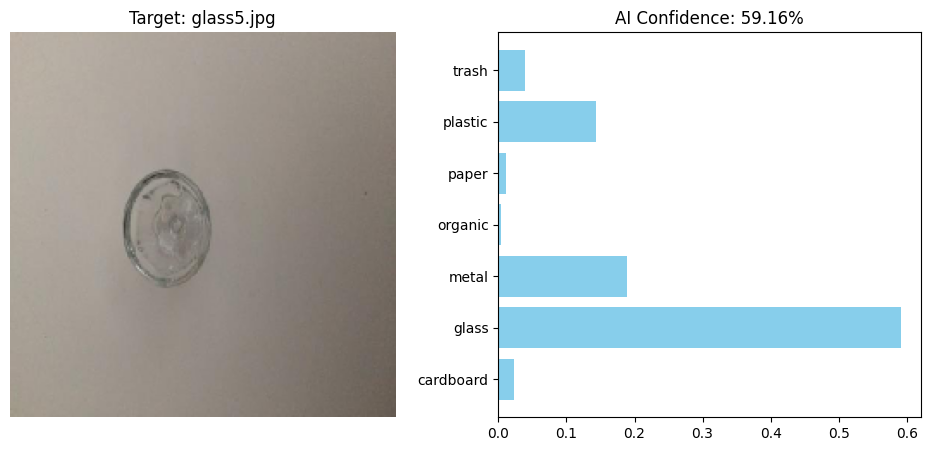

🌐==================================================🌐
✅ AI PREDICTION : GLASS
🗺️ LOCATION      : Japan (Language: ja)
🗑️ RECOMMENDED BIN: BLUE/CRATES BIN
----------------------------------------------------
📍 LIFECYCLE    : 再利用可能/リサイクル可能
🛠️ ACTION       : 洗って保存瓶や装飾品として再利用できます。
📢 SAFETY       : 🐾 動物の安全: 路上の動物が怪我をしないように、厚い紙/段ボールで包みます。
🌐==================================================🌐



In [5]:
def run_recycle_easy_test(target_country="India"):
    print(f"🌍 Testing RecycleEasy for: {target_country.upper()}")
    uploaded = files.upload()

    for fn in uploaded.keys():
        # A. Pre-process Image
        img = image.load_img(fn, target_size=(224, 224))
        x = image.img_to_array(img) / 255.0
        x = np.expand_dims(x, axis=0)

        # B. AI Prediction
        preds = model.predict(x)[0]
        max_idx = np.argmax(preds)
        confidence = preds[max_idx] * 100
        material_detected = LABELS[max_idx]

        # C. Get Multilingual & Global Logic from Engine
        # We pass (material, country, database) to your .py file
        logic = re.get_global_guidance(material_detected, target_country, df_bins)

        # D. Display Visual Results
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(img); plt.axis('off'); plt.title(f"Target: {fn}")

        plt.subplot(1, 2, 2)
        plt.barh(LABELS, preds, color='skyblue')
        plt.title(f"AI Confidence: {confidence:.2f}%")
        plt.show()

        # E. Final Multilingual Output
        print("🌐" + "="*50 + "🌐")
        print(f"✅ AI PREDICTION : {logic['material']}")
        print(f"🗺️ LOCATION      : {logic['country']} (Language: {logic['language']})")
        print(f"🗑️ RECOMMENDED BIN: {logic['bin']}")
        print("-" * 52)
        print(f"📍 LIFECYCLE    : {logic['lifecycle']}")
        print(f"🛠️ ACTION       : {logic['action']}")
        print(f"📢 SAFETY       : {logic['safety']}")
        print("🌐" + "="*50 + "🌐\n")

# Run the test! Try "Japan", "Germany", "France", or "India"
run_recycle_easy_test(target_country="Japan")